# Data Cleaning and Preprocessing Notebook

This Jupyter Notebook provides a step-by-step approach to cleaning and preprocessing a dataset containing various fuel and ignition-related parameters. The main goal is to prepare the data for further analysis or modeling by ensuring consistency, removing noise, and addressing common data quality issues.

First, we define all our libraries and dataframe to be used

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import seaborn as sns
import re
import shap # For SHAP method execution
from sklearn.ensemble import RandomForestRegressor # For construction of surrogate model
from sklearn.model_selection import train_test_split # For training and testing of the model
from sklearn.preprocessing import LabelEncoder # For encoding categorical features
from pprint import pprint # Import pprint for pretty printing


/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Load our df
full_df = pd.read_csv("./data/250710-bp3d-db-data.csv")

We explore the columns of the dataframe, as well as some of its values.

In [5]:
# Keep only the columns that we need, based in Ismael and Pedro's analysis.
columns_to_keep = ['fuel_id',
                   'unit_feature_id',
                   'run_parameters',
                   'ignition_parameters',
                   'ignition_pattern',
                   'metrics', 
                   'qf_parameters']
sub_df = full_df[columns_to_keep]

We proceed by finding replicated rows of the dataframe, and removing them.

In [6]:
def remove_duplicates(df):
    """
    Detects and removes duplicate rows from the DataFrame based on fuel_id

    Args:
        df (pd.DataFrame): DataFrame to clean.

    Returns:
        pd.DataFrame: DataFrame without duplicate rows.
    """
    num_dups = df.duplicated().sum()
    print(f"Duplicate rows found: {num_dups}")

    if num_dups > 0:
        df = df.drop_duplicates().reset_index(drop=True)
        print(f"Duplicates removed. New DataFrame shape: {df.shape}")
    else:
        print("No duplicates found.")
    
    return df

remove_duplicates(sub_df)
len(sub_df)

Duplicate rows found: 0
No duplicates found.


14018

Now, we will create our working df. This needs a few tricks. 

### a. Cleaning the `ignition_parameters`,`ignition_pattern`, `metrics` and `run_parameters` columns

In [7]:
# We need to format the ignition parameters column

# Helper function 
def clean_json_string(json_str):
    """
    Cleans a string to make it a valid JSON string by handling single quotes, 
    Python booleans/None, and trailing commas.
    """
    if not isinstance(json_str, str):
        return None  # Skip non-string entries
    json_str = json_str.replace("'", '"')
    json_str = re.sub(r'\bTrue\b', 'true', json_str)
    json_str = re.sub(r'\bFalse\b', 'false', json_str)
    json_str = re.sub(r'\bNone\b', 'null', json_str)  
    json_str = re.sub(r',(\s*[\]}])', r'\1', json_str)
    return json_str

# str -> JSON
# Apply the cleaning function and parse JSON
def parse_json_column(df, column):
    """
    Parses a DataFrame column containing JSON-like strings into actual JSON objects.
    It cleans the strings first using clean_json_string and handles parsing errors.

    Args:
        df (pd.DataFrame): The DataFrame containing the column to parse.
        column (str): The name of the column containing JSON-like strings.

    Returns:
        list: A list of indices where JSON parsing failed.
    """
    cleaned_data = []
    error_indexes = []
    
    # Iterate through each item in the specified column along with its index
    for idx, item in df[column].items():  
        # Clean the string using the helper function
        cleaned_str = clean_json_string(item)
        
        try:
            # Attempt to parse the cleaned string into a JSON object
            # If cleaned_str is None or empty after cleaning, append None
            parsed_json = json.loads(cleaned_str) if cleaned_str else None
            cleaned_data.append(parsed_json)
        except json.JSONDecodeError:
            # If parsing fails, record the index and append None to cleaned_data
            error_indexes.append(idx)  # Save the index for rows that failed to parse
            cleaned_data.append(None)  # Mark failed parses as None
            
    # Add the parsed data (or None for failures) as a new column in the DataFrame
    # The new column will be named 'parsed_originalColumnName'
    df.loc[:,f'parsed_{column}'] = cleaned_data
    
    # Return the list of indices where parsing errors occurred
    return error_indexes

# GENERAL FUNCTION TO CLEAN NULL VALUES FROM KEY COLUMNS
def drop_null_rows(df, column_names):
    """
    Drops rows from the DataFrame `df` where the columns in `column_names` have null values.
    
    Args:
        df (pd.DataFrame): The DataFrame to clean.
        column_names (list): List of column names to check.
    
    Returns:
        pd.DataFrame: A new DataFrame without rows that have null values in the specified columns.
    """
    for col in column_names:
        null_indexes = df[df[col].isnull()].index.tolist()
        if null_indexes:
            print(f"Dropping {len(null_indexes)} rows due to null values in '{col}'")
            df = df.drop(index=null_indexes).reset_index(drop=True)
    return df

In [8]:
# This list specifies the names of the DataFrame columns that are expected to contain
# JSON-like strings and need to be converted into proper JSON
json_columns = ['run_parameters', 'ignition_parameters', 'ignition_pattern', 'metrics', 'qf_parameters']

# Loop to clean and parse JSON columns
for col in json_columns:
    print(f"Processing column: {col}")
    # Call the 'parse_json_column' function to clean and parse the JSON strings
    # in the current column ('col') of the DataFrame ('sub_df').
    # This function adds a new column (e.g., 'parsed_run_parameters') to 'sub_df'
    # with the converted JSON objects, and returns a list of indices where parsing failed.
    error_indices = parse_json_column(sub_df, col)
    
    # Print the number of rows where JSON parsing failed for the current column.
    print(f"Parsing errors in {col}: {len(error_indices)}")





Processing column: run_parameters


/tmp/ipykernel_151/1189511972.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:,f'parsed_{column}'] = cleaned_data


Parsing errors in run_parameters: 0
Processing column: ignition_parameters


/tmp/ipykernel_151/1189511972.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:,f'parsed_{column}'] = cleaned_data


Parsing errors in ignition_parameters: 0
Processing column: ignition_pattern


/tmp/ipykernel_151/1189511972.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:,f'parsed_{column}'] = cleaned_data


Parsing errors in ignition_pattern: 0
Processing column: metrics
Parsing errors in metrics: 0
Processing column: qf_parameters
Parsing errors in qf_parameters: 0


/tmp/ipykernel_151/1189511972.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:,f'parsed_{column}'] = cleaned_data
/tmp/ipykernel_151/1189511972.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:,f'parsed_{column}'] = cleaned_data


In [9]:
len(sub_df)

14018

We may observe we have 8,039 observations inside the dataframe.

First, we create a list of the names of the newly generated columns. These are the columns that resulted from the JSON parsing process (e.g., 'parsed_run_parameters', 'parsed_metrics'). It's assumed that 'json_columns' is a pre-defined list containing the original column names.

In [10]:
# Remove rows with null values in the parsed columns
# Create a new list containing the names of the newly created parsed columns.
# These names follow the pattern 'parsed_originalcolumnname'.
parsed_columns = [f"parsed_{col}" for col in json_columns]

Now, use the 'drop_null_rows' function to perform the actual cleaning. This function iterates through each column in 'parsed_columns'. For every column, it identifies rows containing any null values (e.g., from failed JSON parsing) and removes those entire rows from the DataFrame. The result is a 'sub_df' that only contains rows where all the specified 'parsed_columns' have valid, non-null data.

In [11]:
# Use the 'drop_null_rows' function to remove any rows from 'sub_df'
# where there are null values (including those resulting from failed JSON parsing)
# in any of the newly created 'parsed_' columns.
# This ensures that all key parsed columns have valid data.
sub_df = drop_null_rows(sub_df, parsed_columns)

Dropping 2547 rows due to null values in 'parsed_ignition_parameters'
Dropping 3 rows due to null values in 'parsed_metrics'
Dropping 3429 rows due to null values in 'parsed_qf_parameters'


Finally, display the number of rows remaining in the DataFrame after the cleaning process. This gives a quick overview of how many rows were kept and how many were dropped due to nulls.

In [12]:
sub_df

,fuel_id,unit_feature_id,run_parameters,ignition_parameters,ignition_pattern,metrics,qf_parameters,parsed_run_parameters,parsed_ignition_parameters,parsed_ignition_pattern,parsed_metrics,parsed_qf_parameters
0,3023,14,"{'dz': None, 'seed': 222, 'topo': {'topo_calcs...","{'crew': [{'velocity': 0.8940545373267769, 'ga...","{'type': 'FeatureCollection', 'features': [{'t...",{'consumption_all_levels': [0.3528712093830108...,"{'output': {'wind': False, 'emissions': False,...","{'dz': None, 'seed': 222, 'topo': {'topo_calcs...","{'crew': [{'velocity': 0.8940545373267769, 'ga...","{'type': 'FeatureCollection', 'features': [{'t...",{'consumption_all_levels': [0.3528712093830108...,"{'output': {'wind': False, 'emissions': False,..."
1,3023,14,"{'dz': None, 'seed': 222, 'topo': {'topo_calcs...","{'crew': [{'velocity': 0.8940545373267769, 'ga...","{'type': 'FeatureCollection', 'features': [{'t...",{'consumption_all_levels': [0.3723344802856445...,"{'output': {'wind': False, 'emissions': False,...","{'dz': None, 'seed': 222, 'topo': {'topo_calcs...","{'crew': [{'velocity': 0.8940545373267769, 'ga...","{'type': 'FeatureCollection', 'features': [{'t...",{'consumption_all_levels': [0.3723344802856445...,"{'output': {'wind': False, 'emissions': False,..."
2,3023,14,"{'dz': None, 'seed': 222, 'topo': {'topo_calcs...","{'crew': [{'velocity': 0.8940545373267769, 'ga...","{'type': 'FeatureCollection', 'features': [{'t...",{'consumption_all_levels': [0.3321924507617950...,"{'output': {'wind': False, 'emissions': False,...","{'dz': None, 'seed': 222, 'topo': {'topo_calcs...","{'crew': [{'velocity': 0.8940545373267769, 'ga...","{'type': 'FeatureCollection', 'features': [{'t...",{'consumption_all_levels': [0.3321924507617950...,"{'output': {'wind': False, 'emissions': False,..."
3,2209,2807,"{'dz': None, 'seed': 222, 'topo': {'topo_calcs...","{'crew': [{'velocity': 7, 'gap_length': 49, 'd...","{'type': 'FeatureCollection', 'features': [{'t...",{'consumption_all_levels': [0.1548669040203094...,"{'output': {'wind': False, 'emissions': False,...","{'dz': None, 'seed': 222, 'topo': {'topo_calcs...","{'crew': [{'velocity': 7, 'gap_length': 49, 'd...","{'type': 'FeatureCollection', 'features': [{'t...",{'consumption_all_levels': [0.1548669040203094...,"{'output': {'wind': False, 'emissions': False,..."
4,2209,2807,"{'dz': None, 'seed': 222, 'topo': {'topo_calcs...","{'crew': [{'velocity': 7, 'gap_length': 49, 'd...","{'type': 'FeatureCollection', 'features': [{'t...",{'consumption_all_levels': [0.1400300860404968...,"{'output': {'wind': False, 'emissions': False,...","{'dz': None, 'seed': 222, 'topo': {'topo_calcs...","{'crew': [{'velocity': 7, 'gap_length': 49, 'd...","{'type': 'FeatureCollection', 'features': [{'t...",{'consumption_all_levels': [0.1400300860404968...,"{'output': {'wind': False, 'emissions': False,..."
...,...,...,...,...,...,...,...,...,...,...,...,...
8034,3017,2829,"{'dz': None, 'seed': 222, 'topo': {'topo_calcs...","{'crew': [{'velocity': 0.8940545373267769, 'ga...","{'type': 'FeatureCollection', 'features': [{'t...",{'consumption_all_levels': [0.7167190313339233...,{'output': {}},"{'dz': None, 'seed': 222, 'topo': {'topo_calcs...","{'crew': [{'velocity': 0.8940545373267769, 'ga...","{'type': 'FeatureCollection', 'features': [{'t...",{'consumption_all_levels': [0.7167190313339233...,{'output': {}}
8035,3017,2829,"{'dz': None, 'seed': 222, 'topo': {'topo_calcs...","{'crew': [{'velocity': 0.8940545373267769, 'ga...","{'type': 'FeatureCollection', 'features': [{'t...",{'consumption_all_levels': [0.7439647316932678...,{'output': {}},"{'dz': None, 'seed': 222, 'topo': {'topo_calcs...","{'crew': [{'velocity': 0.8940545373267769, 'ga...","{'type': 'FeatureCollection', 'features': [{'t...",{'consumption_all_levels': [0.7439647316932678...,{'output': {}}
8036,3019,3648,"{'dz': None, 'seed': 222, 'topo': {'topo_calcs...","{'crew': [{'velocity': 0.8940545373267769, 'ga...","{'type': 'FeatureCollection', 'features': [{'t...",{'consumption_all_lev

Now, we proceed by choosing the columns we want to keep when constructing our dataframe, and appending the required data.

In [13]:
# Here, we define the groups that will be visible for the new generated dataframe.
new_df = {'fuel_id':[],
          'unit_feature_id':[],
          'surface_consumed':[], 
          'midstory_consumed':[], 
          'canopy_consumed':[], 
          'fdfm':[], 
          'lfm':[], 
          'wind_speed':[], 
          'wind_direction':[], 
          'wind_height':[],
          'side_to_start_ignition':[], 
          'number_igniters':[], 
          'firing_technique':[], 
          'ignition_type':[], 
          'dash_length':[], 
          'gap_length':[], 
          'blackline_width':[], 
          'spacing_distance':[], 
          'igniter_velocity':[]}

In [14]:
# Appending data
for _, row in sub_df.iterrows():
    
    new_df['fuel_id'].append(row['fuel_id'])
    new_df['unit_feature_id'].append(row['unit_feature_id'])
    new_df['surface_consumed'].append(row['parsed_metrics'].get('inside_surface_consumption', None))
    new_df['midstory_consumed'].append(row['parsed_metrics'].get('consumption_t0_tNone_z1_z5', None))
    new_df['canopy_consumed'].append(row['parsed_metrics'].get('consumption_t0_tNone_z6_zNone', None))
    new_df['fdfm'].append(row['parsed_run_parameters'].get('surface_moisture', None))
    new_df['lfm'].append(row['parsed_run_parameters'].get('canopy_moisture',None))
    new_df['wind_speed'].append(row['parsed_run_parameters'].get('wind_speed', None))
    new_df['wind_direction'].append(row['parsed_run_parameters'].get('wind_direction', None))
    new_df['wind_height'].append(row['parsed_run_parameters'].get('wind_height', None))
    new_df['side_to_start_ignition'].append(row['parsed_ignition_parameters'].get('side', None))
    new_df['number_igniters'].append(len(row['parsed_ignition_parameters']['crew']))
    new_df['firing_technique'].append(row['parsed_ignition_parameters'].get('pattern_type', None))

    if 'dash_length' in row['parsed_ignition_parameters']['crew'][0] and 'gap_length' in row['parsed_ignition_parameters']['crew'][0]:
        new_df['ignition_type'].append('dashes')
        new_df['dash_length'].append(row['parsed_ignition_parameters']['crew'][0]['dash_length'])
        new_df['gap_length'].append(row['parsed_ignition_parameters']['crew'][0]['gap_length'])
    elif 'gap_length' in row['parsed_ignition_parameters']['crew'][0]:
        new_df['ignition_type'].append('dots')
        new_df['gap_length'].append(row['parsed_ignition_parameters']['crew'][0]['gap_length'])
    else:
        new_df['ignition_type'].append('lines')
    
    new_df['blackline_width'].append(row['parsed_ignition_parameters'].get('blackline', None))
    new_df['spacing_distance'].append(row['parsed_ignition_parameters'].get('spacing', None))
    new_df['igniter_velocity'].append(row['parsed_ignition_parameters']['crew'][0].get('velocity', None))


In [15]:
df = pd.DataFrame(new_df)
df.columns

Index(['fuel_id', 'unit_feature_id', 'surface_consumed', 'midstory_consumed',
       'canopy_consumed', 'fdfm', 'lfm', 'wind_speed', 'wind_direction',
       'wind_height', 'side_to_start_ignition', 'number_igniters',
       'firing_technique', 'ignition_type', 'dash_length', 'gap_length',
       'blackline_width', 'spacing_distance', 'igniter_velocity'],
      dtype='object')

In [16]:
# Number of df observations
print(len(df))

8039


We may also observe we have 8,039 observations at the moment, inside the dataframe.

In [17]:
def describe_columns(df, columns=None):
    """
    Describes statistical properties of DataFrame columns.
    Can describe a single column, multiple columns, or all columns (default).

    Parameters:
    -----------
    df : pandas.DataFrame
        The DataFrame to analyze.
    columns : str, list, or None (default=None)
        - If None: describes all columns.
        - If str: describes a single column.
        - If list: describes multiple specified columns.

    Returns:
    --------
    None (prints results to console).
    """
    if columns is None:
        columns = df.columns  # Describe all columns
    elif isinstance(columns, str):
        columns = [columns]  # Convert single column to list for uniform processing
    
    for col in columns:
        try:
            print(f"--- {col} ---")
            print(df[col].describe())
            print("\n")
        except KeyError:
            print(f"Column '{col}' not found in DataFrame.")
        except Exception as e:
            print(f"Could not describe column '{col}': {e}")
describe_columns(df)

--- fuel_id ---
count    8039.000000
mean     2189.735042
std       534.401623
min       569.000000
25%      2084.000000
50%      2215.000000
75%      2588.000000
max      3047.000000
Name: fuel_id, dtype: float64


--- unit_feature_id ---
count    8039.000000
mean     2067.362234
std      1003.120496
min        14.000000
25%       850.000000
50%      2156.000000
75%      2937.000000
max      3648.000000
Name: unit_feature_id, dtype: float64


--- surface_consumed ---
count    8039.000000
mean        0.744542
std         0.256132
min         0.003862
25%         0.654576
50%         0.835379
75%         0.936777
max         0.996155
Name: surface_consumed, dtype: float64


--- midstory_consumed ---
count    6294.000000
mean        0.444521
std         0.233072
min         0.000000
25%         0.269797
50%         0.426376
75%         0.659295
max         0.861364
Name: midstory_consumed, dtype: float64


--- canopy_consumed ---
count    6294.000000
mean        0.093063
std         0.09

Through this analysis, we observe we have outlier values, with 'dash_length', 'gap_length', and 'igniter velocity' variables.

Also, we explore for constant values, and we obtain that 'ignition_type' is a column with constant values.

In [18]:
for key, values in new_df.items():
    if values:  # Checks if the list of values is not empty
        if len(set(values)) == 1: # Checks if all values in the list are the same
            print(f"'{key}' is constant: {values[0]}")
# It seems only 'dashes' is constant; the others are different.
# Ha! Even if it doesn't look like it, there must be other things elsewhere.

'ignition_type' is constant: dashes


## General Summary

### General Notes
- `if` conditions function correctly...?
- `ignition_type`: all records are `"dashes"`.
---

### 1. Variables with Extreme Values or Anomalies

- **`dash_length`**
  - Extremely high mean and standard deviation (~10²⁴ to 10²⁶).
  - Unreasonably high maximum (~6.3e+26).
  - Normal quartiles (~0.6 to 4) suggest data entry or formatting errors.

- **`gap_length`**
  - Similar pattern to `dash_length`: reasonable quartiles but extreme values skew the distribution.

- **`igniter_velocity`**
  - Very high mean (~2.2e+16) while the median is only 2.0.
  - Strongly skewed by outliers, needs cleaning or truncation.

---

### 2. Variables with Missing Data or Limited Coverage

- **`midstory_consumed`** and **`canopy_consumed`**
  - Lower number of records (~19,446 vs 22,936).
  - `canopy_consumed` values are generally low, suggesting limited presence of the measured phenomenon or low sensitivity.

---

### 3. Variables with Reasonable Distributions

- **`surface_consumed`**
  - Well distributed between 0 and 1.
  - High mean (0.74), no significant outliers.

- **`fdfm`**
  - Range between 0.02 and 0.8, with a mean of 0.12; consistent distribution.

- **`lfm`**
  - Mostly between 0.9 and 1.0, though an outlier at 2.46 is present.

- **`wind_speed`**
  - Typical domain between 3.1 and 8.0, but with a maximum of 90; review outliers.

- **`wind_direction`**
  - Circular distribution between 0–360°. No evident anomalies.

- **`wind_height`**
  - Distribution between 5.0000 and 60.0000. No evident anomalies.

---

### 4. Categorical Variables

- **`ignition_type`**
  - Single value ("dashes") for all records; contributes no information and can be dropped.

- **`firing_technique`**
  - Six categories, but `"strip"` dominates with over 80% of occurrences; imbalanced distribution.

- **`side_to_start_ignition`**
  - Two categories, with `"right"` appearing in ~85% of cases; also imbalanced.

---

### 5. Variables That May Affect Sensitivity Analysis

- **`dash_length`**, **`gap_length`**, **`igniter_velocity`**
  - Extreme values and anomalous distributions may distort sensitivity analysis.

- **`ignition_type`**
  - Constant value; no variance, has no impact on sensitivity.

- **`firing_technique`**, **`side_to_start_ignition`**
  - Imbalanced distributions may reduce explanatory power unless rebalanced.


Based on the preceding descriptive analysis, we must address the following:

1) Remove ignition_type: This variable exhibits constant values throughout the dataset.

2) Bound dash_length, gap_length, and igniter_velocity: Outliers within these variables need to be addressed.

3) Assess canopy and other related variables: Evaluate the distribution and frequency of values to determine if any specific actions are required.

4) Review firing_technique and side_to_start_ignition: Determine if any adjustments or treatments are necessary for these variables.

We count the number of observations we have.

In [19]:
# Number of df observations
print(len(df))

8039


We remove 'ignition_type', as it is a constant value.

In [20]:
# 1) Remove 'ignition_type':
del new_df['ignition_type']
# You can only run this once.
# If you try to run it again, it will raise an error
# because the deleted column will no longer exist.

In [21]:
# We need to reload the information into the DataFrame.
df = pd.DataFrame(new_df)
# Let's check the column names and
# observe that 'ignition_type' is no longer present.
print(list(df.columns))

['fuel_id', 'unit_feature_id', 'surface_consumed', 'midstory_consumed', 'canopy_consumed', 'fdfm', 'lfm', 'wind_speed', 'wind_direction', 'wind_height', 'side_to_start_ignition', 'number_igniters', 'firing_technique', 'dash_length', 'gap_length', 'blackline_width', 'spacing_distance', 'igniter_velocity']


We define our input list, and continue removing outliers for the columns that registered them (by removing all values bigger than 100).

In [23]:
# Step by step debugging

# Apply each filter individually to see the impact
df_temp = df.copy()

# Inputs Based on Dataframe
inputs_list = ['fdfm','lfm','wind_speed', 'wind_direction', 'wind_height', 'dash_length', 'gap_length',
          'blackline_width', 'spacing_distance', 'igniter_velocity', 
          'side_to_start_ignition', 'firing_technique'] 

# Apply each filter individually to see the impact
print(f"Starting with: {len(df_temp)} rows")

df_temp = df_temp[(df_temp['dash_length'] <= 100) | (df_temp['dash_length'].isna())]
print(f"After dash_length <= 100 (keeping NaN): {len(df_temp)} rows")

df_temp = df_temp[(df_temp['gap_length'] <= 100) | (df_temp['gap_length'].isna())]  
print(f"After gap_length <= 100 (keeping NaN): {len(df_temp)} rows")

df_temp = df_temp[(df_temp['igniter_velocity'] <= 100) | (df_temp['igniter_velocity'].isna())]
print(f"After igniter_velocity <= 100 (keeping NaN): {len(df_temp)} rows")

print(f"Ending with: {len(df_temp)} rows")



Starting with: 8039 rows
After dash_length <= 100 (keeping NaN): 7994 rows
After gap_length <= 100 (keeping NaN): 7922 rows
After igniter_velocity <= 100 (keeping NaN): 7886 rows
Ending with: 7886 rows


In [24]:
describe_columns(df_temp)

--- fuel_id ---
count    7886.000000
mean     2190.860893
std       539.455974
min       569.000000
25%      2068.000000
50%      2229.000000
75%      2588.000000
max      3047.000000
Name: fuel_id, dtype: float64


--- unit_feature_id ---
count    7886.000000
mean     2061.524854
std      1010.285052
min        14.000000
25%       743.000000
50%      2141.000000
75%      2944.000000
max      3648.000000
Name: unit_feature_id, dtype: float64


--- surface_consumed ---
count    7886.000000
mean        0.745656
std         0.257729
min         0.003862
25%         0.655521
50%         0.839176
75%         0.938392
max         0.996155
Name: surface_consumed, dtype: float64


--- midstory_consumed ---
count    6177.000000
mean        0.446969
std         0.233155
min         0.000000
25%         0.275602
50%         0.428938
75%         0.661295
max         0.861364
Name: midstory_consumed, dtype: float64


--- canopy_consumed ---
count    6177.000000
mean        0.093536
std         0.09

Through this analysis, we can also observe that no more outliers are registered.

Now, we may visualize the input distribution of each column, with both continuous and discrete inputs.

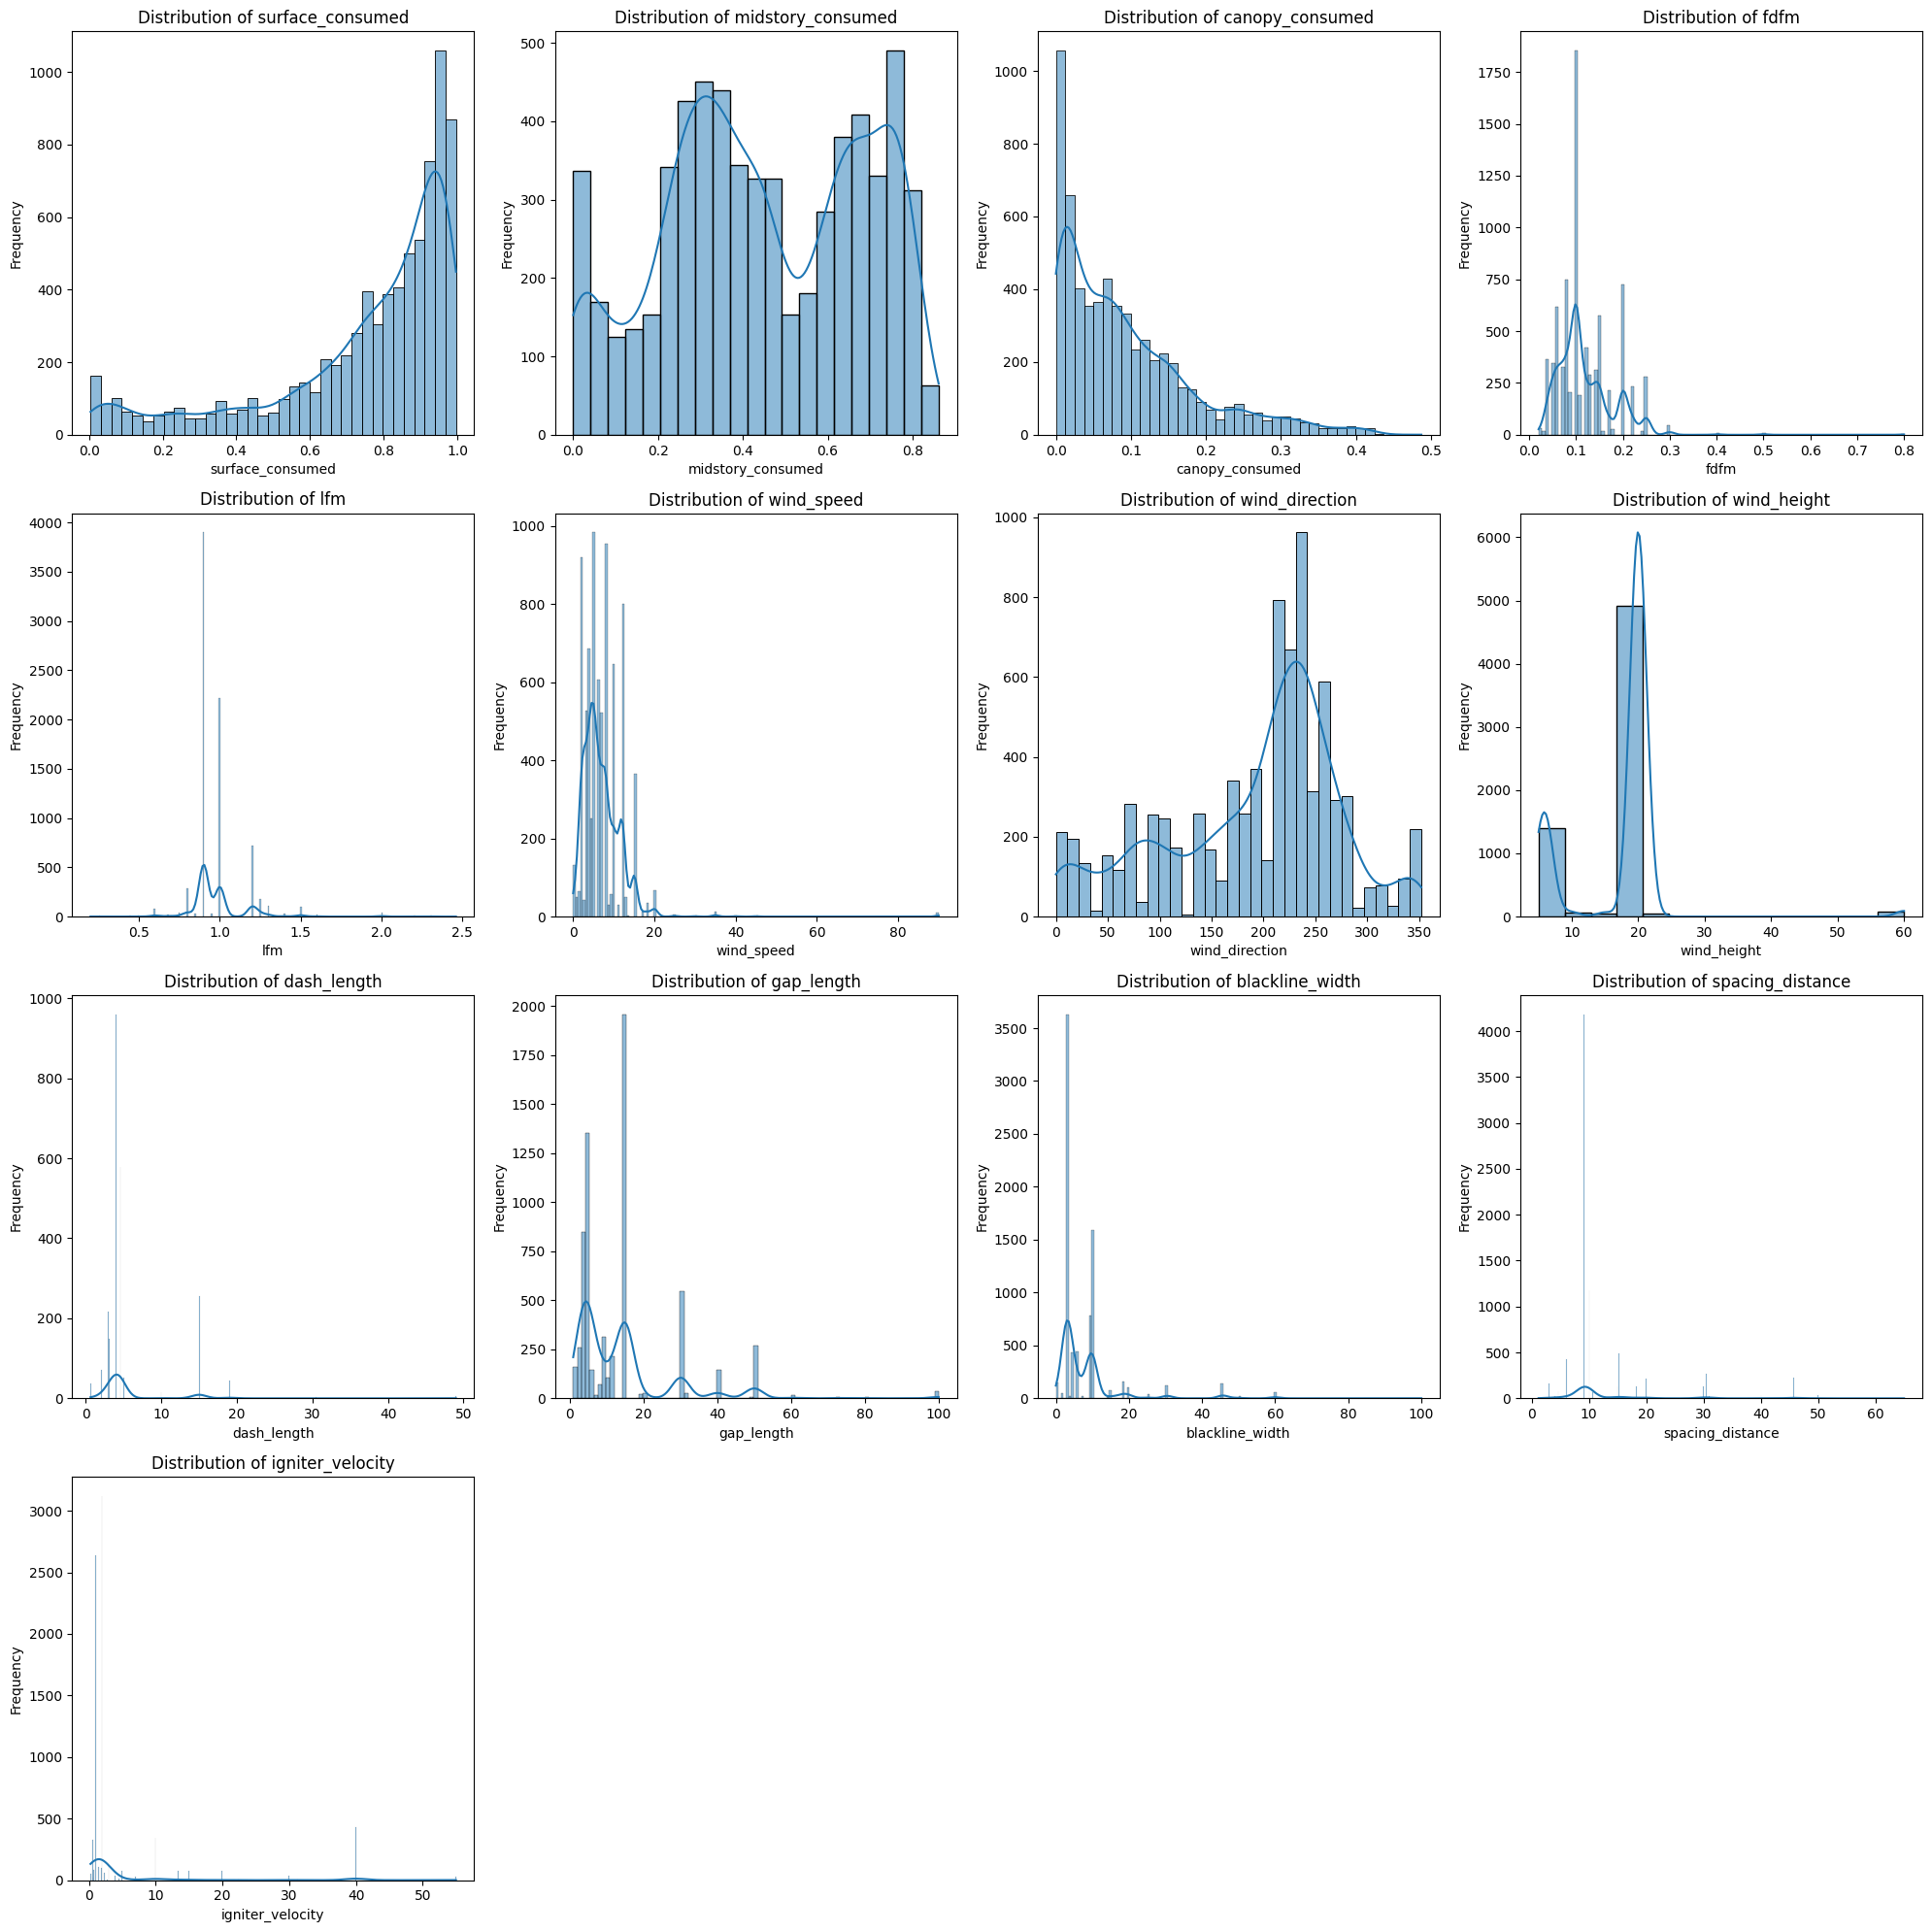

In [25]:
# Contiuous features
continuous_columns = ['surface_consumed', 'midstory_consumed', 'canopy_consumed', 'fdfm',
                     'lfm','wind_speed', 'wind_direction', 'wind_height','dash_length', 'gap_length',
                     'blackline_width', 'spacing_distance', 'igniter_velocity']  

num_columns = len(continuous_columns)
rows = (num_columns + 3) // 4  # Number of rows needed for a 4-column grid

# Plot each column in the grid
plt.figure(figsize=(20, 5 * rows))
for i, col in enumerate(continuous_columns, 1):
    plt.subplot(rows, 4, i)
    sns.histplot(df_temp[col].dropna(), kde=True)  # Drop NaN for clean distribution, add KDE for smooth curve
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

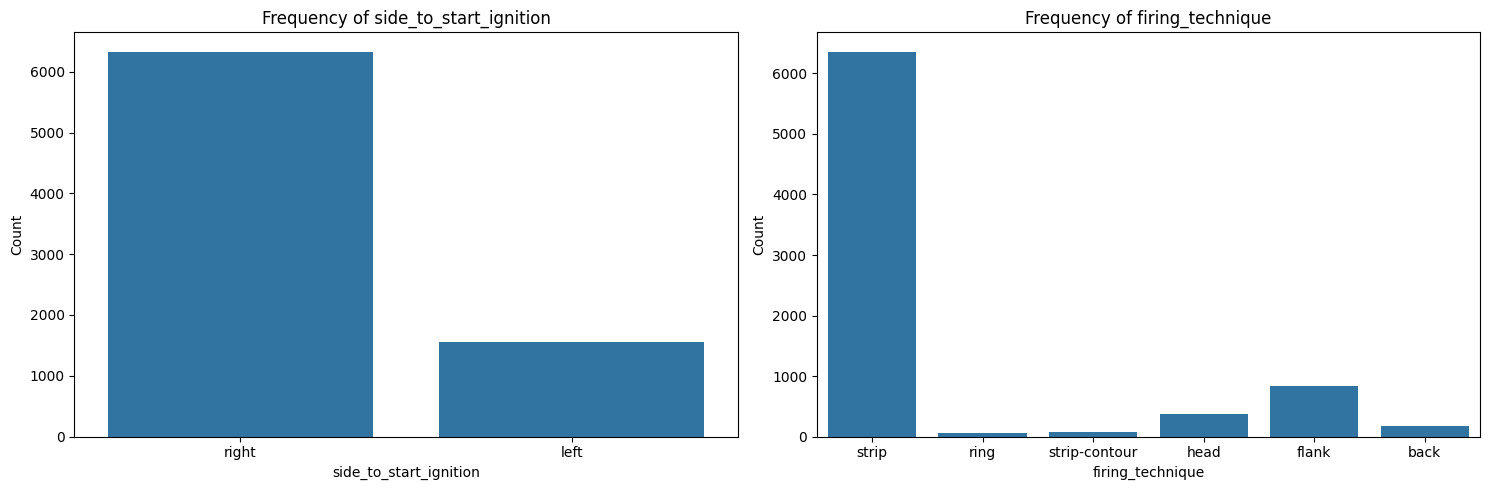

In [26]:
# Discrete features
discrete_columns = ['side_to_start_ignition', 'firing_technique' ]

num_columns = len(discrete_columns)

plt.figure(figsize=(15, 5))
for i, col in enumerate(discrete_columns, 1):
    plt.subplot(1, num_columns, i)
    sns.countplot(data=df_temp, x=col)
    plt.title(f'Frequency of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

Previous to the sensitivity analysis, and during the data preprocessing, it is necessary to encode the discrete variables, so they may be taken into account and participate during the continuous analysis, as all the model inputs are continuous.

In [27]:
# Variables Encoding
label_encoders = {}

for col in discrete_columns:
    le = LabelEncoder()
    df_temp[col] = le.fit_transform(df_temp[col])
    label_encoders[col] = le

Now, we have 4 options for more data preprocessing before the sensitivity analysis, based on which kind of analysis we are looking for:

1. Remove all rows with a single or more NaN inputs.
2. Impute median to NaN inputs.
3. Remove 'dash_length' column, and all rows with a single or more NaN inputs.
4. Remove 'dash_length' column, and impute median to NaN inputs.

Now, we load our new cleaned dataframe as a csv file, ready for the sensitivity analysis

In [28]:
df_temp
df_temp.to_csv('./data/cleaned_df.csv', index=False)
# df_cleaned
# df_cleaned.to_csv('./data/cleaned_df.csv', index=False)